In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import optuna
from tqdm import tqdm
import logging
import sys


c:\Users\Admin\miniconda3\envs\smog\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================
# Настройка логирования
# ============================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger(__name__)

# Фиксируем случайные seed'ы для воспроизводимости
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
# Определим устройство (GPU, если доступен)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Используемое устройство: {device}")

2026-06-01 10:21:01,227 [INFO] Используемое устройство: cuda


In [4]:
# ============================
# 1. Генерация датасета
# ============================
def target_function(x, y):
    """Истинная функция: f(x,y) = sin(x + 2y) * exp(-(2x + y)^2)"""
    return np.sin(x + 2 * y) * np.exp(-((2 * x + y) ** 2))

# Генерируем 20 000 точек в диапазоне [-10, 10] по обеим координатам
num_samples = 20_000
X = np.random.uniform(-10, 10, size=(num_samples, 2))
y = target_function(X[:, 0], X[:, 1]).reshape(-1, 1)

logger.info(f"Сгенерировано {num_samples} точек. Размер X: {X.shape}, y: {y.shape}")

2026-06-01 10:21:15,397 [INFO] Сгенерировано 20000 точек. Размер X: (20000, 2), y: (20000, 1)


In [5]:
# ============================
# 2. Разделение на train / val / test (70 / 15 / 15)
# ============================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)

logger.info(
    f"Размеры выборок: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}"
)

2026-06-01 10:21:28,425 [INFO] Размеры выборок: train=14000, val=3000, test=3000


In [6]:
# Преобразуем в тензоры и создаём Dataset/DataLoader
def create_dataloader(X_data, y_data, batch_size=64, shuffle=True):
    tensor_x = torch.FloatTensor(X_data)
    tensor_y = torch.FloatTensor(y_data)
    dataset = TensorDataset(tensor_x, tensor_y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return loader

# Базовый batch_size
base_batch_size = 64
train_loader = create_dataloader(X_train, y_train, base_batch_size, shuffle=True)
val_loader   = create_dataloader(X_val, y_val, base_batch_size, shuffle=False)
test_loader  = create_dataloader(X_test, y_test, base_batch_size, shuffle=False)

In [8]:
# ============================
# 3. Базовая модель
# ============================
class RegressionModel(nn.Module):
    """Полносвязная нейронная сеть для регрессии."""
    def __init__(self, input_dim=2, hidden_dims=[64, 64], activation=nn.ReLU):
        super(RegressionModel, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(activation())
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))  # выходной слой
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Базовая архитектура
base_model = RegressionModel(
    input_dim=2,
    hidden_dims=[64, 64],
    activation=nn.ReLU
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(base_model.parameters(), lr=0.001)

# ============================
# Функция обучения одного этапа (эпохи)
# ============================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
    return running_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            running_loss += loss.item() * batch_x.size(0)
    return running_loss / len(loader.dataset)

In [9]:
# ============================
# 4. Обучение базовой модели с прогресс-баром
# ============================
num_epochs_base = 200
logger.info("Начинаем обучение базовой модели...")
train_losses_base = []
val_losses_base = []

for epoch in tqdm(range(num_epochs_base), desc="Base model training"):
    train_loss = train_epoch(base_model, train_loader, optimizer, criterion)
    val_loss = evaluate(base_model, val_loader, criterion)
    train_losses_base.append(train_loss)
    val_losses_base.append(val_loss)
    if (epoch+1) % 20 == 0:
        logger.info(f"Epoch {epoch+1:3d}/{num_epochs_base} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# MSE на тесте для базовой модели
base_test_mse = evaluate(base_model, test_loader, criterion)
logger.info(f"Базоая модель – Test MSE: {base_test_mse:.6f}")

2026-06-01 10:24:07,690 [INFO] Начинаем обучение базовой модели...


Base model training:  10%|▉         | 19/200 [00:05<00:55,  3.25it/s]

2026-06-01 10:24:13,591 [INFO] Epoch  20/200 | Train Loss: 0.010009 | Val Loss: 0.007616


Base model training:  20%|█▉        | 39/200 [00:11<00:43,  3.67it/s]

2026-06-01 10:24:19,021 [INFO] Epoch  40/200 | Train Loss: 0.008673 | Val Loss: 0.007297


...

2026-06-01 10:25:03,881 [INFO] Epoch 180/200 | Train Loss: 0.002375 | Val Loss: 0.002227


Base model training: 100%|█████████▉| 199/200 [01:02<00:00,  3.18it/s]

2026-06-01 10:25:10,152 [INFO] Epoch 200/200 | Train Loss: 0.002221 | Val Loss: 0.002100


Base model training: 100%|██████████| 200/200 [01:02<00:00,  3.20it/s]

2026-06-01 10:25:10,181 [INFO] Базоая модель – Test MSE: 0.003054


In [10]:
# ============================
# 5. Optuna: подбор архитектуры и гиперпараметров
# ============================
def objective(trial):
    """Функция-обёртка для одного испытания Optuna.
    Возвращает ошибку на валидационной выборке."""
    # Гиперпараметры для поиска
    n_layers = trial.suggest_int("n_layers", 1, 4)
    hidden_units = trial.suggest_categorical("hidden_units", [32, 64, 128, 256])
    activation_name = trial.suggest_categorical("activation", ["ReLU", "Tanh", "LeakyReLU"])
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])
    loss_name = trial.suggest_categorical("loss", ["MSE", "Huber", "SmoothL1"])

    # Создаём архитектуру
    hidden_dims = [hidden_units] * n_layers
    act_map = {
        "ReLU": nn.ReLU,
        "Tanh": nn.Tanh,
        "LeakyReLU": nn.LeakyReLU
    }
    activation = act_map[activation_name]

    model = RegressionModel(2, hidden_dims, activation).to(device)

    # Функция потерь
    if loss_name == "MSE":
        loss_fn = nn.MSELoss()
    elif loss_name == "Huber":
        loss_fn = nn.HuberLoss()
    else:  # SmoothL1
        loss_fn = nn.SmoothL1Loss()

    # Оптимизатор
    if optimizer_name == "Adam":
        opt = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:  # RMSprop
        opt = optim.RMSprop(model.parameters(), lr=lr)

    # DataLoader с текущим batch_size
    train_loader_opt = create_dataloader(X_train, y_train, batch_size=batch_size, shuffle=True)
    val_loader_opt   = create_dataloader(X_val, y_val, batch_size=batch_size, shuffle=False)

    # Обучаем несколько эпох (чтобы сэкономить время – 50 эпох)
    num_epochs_opt = 50
    for _ in range(num_epochs_opt):
        train_epoch(model, train_loader_opt, opt, loss_fn)

    # Итоговая ошибка на валидации
    val_loss = evaluate(model, val_loader_opt, loss_fn)
    return val_loss


In [11]:
# Запускаем оптимизацию (10 испытаний – для демонстрации; можно увеличить)
logger.info("Запуск Optuna для поиска лучших гиперпараметров...")
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

best_params = study.best_params
logger.info(f"Лучшие параметры: {best_params}")
logger.info(f"Лучшее значение (val loss): {study.best_value:.6f}")

# ============================
# 6. Обучение финальной модели с лучшими параметрами
# ============================
# Объединяем train и val для финального обучения
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.vstack([y_train, y_val])

# Извлекаем лучшие гиперпараметры
n_layers_best = best_params["n_layers"]
hidden_units_best = best_params["hidden_units"]
activation_best_name = best_params["activation"]
lr_best = best_params["lr"]
batch_size_best = best_params["batch_size"]
optimizer_best_name = best_params["optimizer"]
loss_best_name = best_params["loss"]

act_map = {"ReLU": nn.ReLU, "Tanh": nn.Tanh, "LeakyReLU": nn.LeakyReLU}
activation_best = act_map[activation_best_name]

final_model = RegressionModel(
    2,
    [hidden_units_best] * n_layers_best,
    activation_best
).to(device)

if loss_best_name == "MSE":
    final_criterion = nn.MSELoss()
elif loss_best_name == "Huber":
    final_criterion = nn.HuberLoss()
else:
    final_criterion = nn.SmoothL1Loss()

if optimizer_best_name == "Adam":
    final_optimizer = optim.Adam(final_model.parameters(), lr=lr_best)
elif optimizer_best_name == "SGD":
    final_optimizer = optim.SGD(final_model.parameters(), lr=lr_best, momentum=0.9)
else:
    final_optimizer = optim.RMSprop(final_model.parameters(), lr=lr_best)

final_train_loader = create_dataloader(X_trainval, y_trainval, batch_size_best, shuffle=True)
final_test_loader = create_dataloader(X_test, y_test, batch_size_best, shuffle=False)

2026-06-01 10:25:21,195 [INFO] Запуск Optuna для поиска лучших гиперпараметров...


[I 2026-06-01 10:25:21,196] A new study created in memory with name: no-name-ca64f158-e2a0-41d8-9aa4-6e9c72d55171
Best trial: 0. Best value: 0.0154561:  10%|█         | 1/10 [00:07<01:04,  7.17s/it]

[I 2026-06-01 10:25:28,362] Trial 0 finished with value: 0.015456099440654118 and parameters: {'n_layers': 1, 'hidden_units': 128, 'activation': 'LeakyReLU', 'lr': 0.0004958510450582746, 'batch_size': 128, 'optimizer': 'SGD', 'loss': 'MSE'}. Best is trial 0 with value: 0.015456099440654118.


Best trial: 1. Best value: 0.0151999:  20%|██        | 2/10 [00:22<01:36, 12.11s/it]

[I 2026-06-01 10:25:43,925] Trial 1 finished with value: 0.01519988650518159 and parameters: {'n_layers': 4, 'hidden_units': 128, 'activation': 'ReLU', 'lr': 0.0002649998670651875, 'batch_size': 64, 'optimizer': 'SGD', 'loss': 'MSE'}. Best is trial 1 with value: 0.01519988650518159.


...

[I 2026-06-01 10:27:29,663] Trial 7 finished with value: 0.001377727206214331 and parameters: {'n_layers': 3, 'hidden_units': 256, 'activation': 'Tanh', 'lr': 0.00033014061219425957, 'batch_size': 32, 'optimizer': 'RMSprop', 'loss': 'Huber'}. Best is trial 5 with value: 0.00040787444477124763.


Best trial: 5. Best value: 0.000407874:  90%|█████████ | 9/10 [02:20<00:17, 17.60s/it]

[I 2026-06-01 10:27:41,808] Trial 8 finished with value: 0.006566223001107574 and parameters: {'n_layers': 2, 'hidden_units': 64, 'activation': 'ReLU', 'lr': 0.007620629628075546, 'batch_size': 64, 'optimizer': 'SGD', 'loss': 'SmoothL1'}. Best is trial 5 with value: 0.00040787444477124763.


Best trial: 5. Best value: 0.000407874: 100%|██████████| 10/10 [02:34<00:00, 15.46s/it]

[I 2026-06-01 10:27:55,756] Trial 9 finished with value: 0.007808704804008206 and parameters: {'n_layers': 4, 'hidden_units': 32, 'activation': 'ReLU', 'lr': 0.00023552673951661687, 'batch_size': 64, 'optimizer': 'SGD', 'loss': 'SmoothL1'}. Best is trial 5 with value: 0.00040787444477124763.
2026-06-01 10:27:55,759 [INFO] Лучшие параметры: {'n_layers': 4, 'hidden_units': 128, 'activation': 'Tanh', 'lr': 0.0006775548129944136, 'batch_size': 64, 'optimizer': 'Adam', 'loss': 'Huber'}
2026-06-01 10:27:55,759 [INFO] Лучшее значение (val loss): 0.000408


In [12]:
# Обучаем финальную модель (можно взять больше эпох, например 200)
logger.info("Обучение финальной модели с лучшими параметрами Optuna...")
num_epochs_final = 200
for epoch in tqdm(range(num_epochs_final), desc="Final model training"):
    train_epoch(final_model, final_train_loader, final_optimizer, final_criterion)
    if (epoch+1) % 20 == 0:
        val_loss = evaluate(final_model, final_test_loader, final_criterion)
        logger.info(f"Epoch {epoch+1:3d}/{num_epochs_final} | Test Loss (для контроля): {val_loss:.6f}")

# MSE на тесте для оптимизированной модели
optuna_test_mse = evaluate(final_model, final_test_loader, nn.MSELoss())  # всегда считаем MSE для метрики
logger.info(f"Optuna модель – Test MSE: {optuna_test_mse:.6f}")


2026-06-01 10:27:55,779 [INFO] Обучение финальной модели с лучшими параметрами Optuna...


Final model training:  10%|▉         | 19/200 [00:07<01:06,  2.72it/s]

2026-06-01 10:28:03,329 [INFO] Epoch  20/200 | Test Loss (для контроля): 0.006981


Final model training:  20%|█▉        | 39/200 [00:14<00:59,  2.72it/s]

2026-06-01 10:28:10,710 [INFO] Epoch  40/200 | Test Loss (для контроля): 0.000414


...

2026-06-01 10:29:03,029 [INFO] Epoch 180/200 | Test Loss (для контроля): 0.000142


Final model training: 100%|█████████▉| 199/200 [01:14<00:00,  2.69it/s]

2026-06-01 10:29:10,466 [INFO] Epoch 200/200 | Test Loss (для контроля): 0.000064


Final model training: 100%|██████████| 200/200 [01:14<00:00,  2.68it/s]

2026-06-01 10:29:10,501 [INFO] Optuna модель – Test MSE: 0.000129


In [13]:
# ============================
# 7. Сравнительная таблица MSE на тесте
# ============================
print("\n========== Сравнение MSE на тестовой выборке ==========")
print(f"{'Модель':<25} {'Test MSE':<15}")
print("-" * 40)
print(f"{'Базовая (ReLU, 2x64)':<25} {base_test_mse:<15.6f}")
print(f"{'Optuna (лучшая)':<25} {optuna_test_mse:<15.6f}")
print("========================================================")


========== Сравнение MSE на тестовой выборке ==========
Модель                    Test MSE       
----------------------------------------
Базовая (ReLU, 2x64)      0.003054       
Optuna (лучшая)           0.000129       


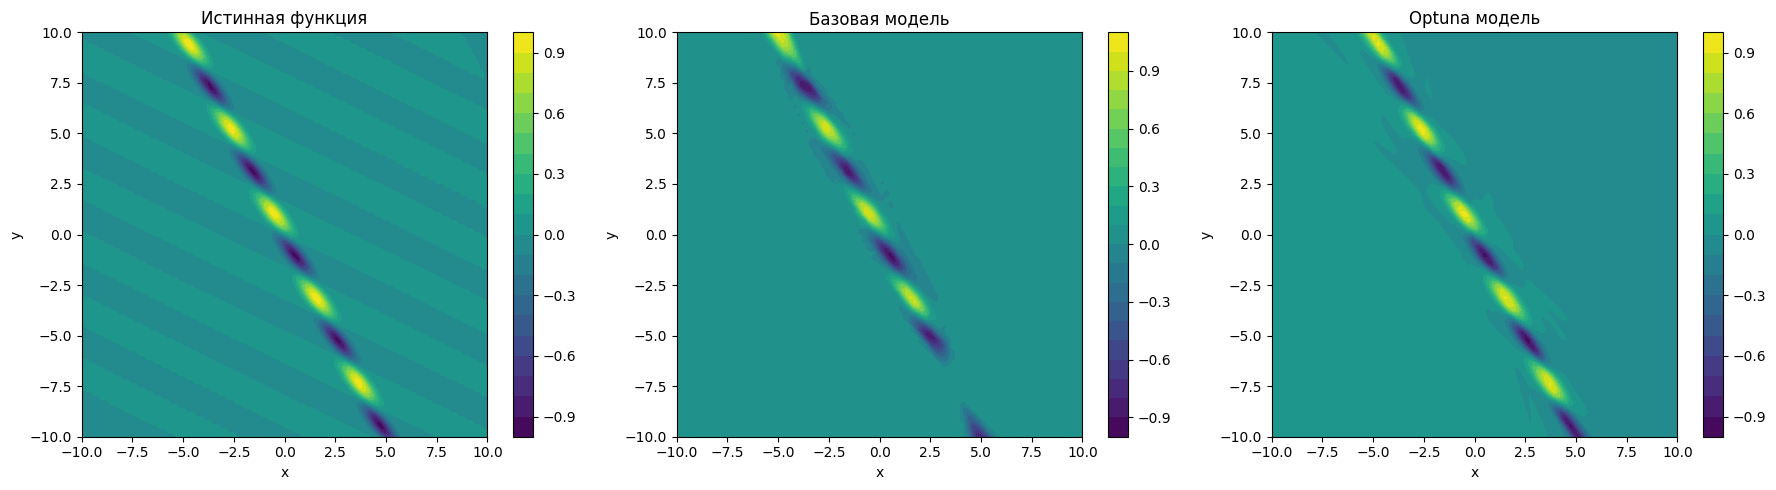

2026-06-01 10:29:11,189 [INFO] График сравнения сохранён в comparison_plot.png


In [14]:
# ============================
# 8. Визуализация: сравнение истинной функции и предсказаний
# ============================
# Создаём сетку для отрисовки
grid_size = 100
x_grid = np.linspace(-10, 10, grid_size)
y_grid = np.linspace(-10, 10, grid_size)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
grid_points = np.c_[X_grid.ravel(), Y_grid.ravel()]

# Истинные значения
Z_true = target_function(grid_points[:, 0], grid_points[:, 1]).reshape(grid_size, grid_size)

# Предсказания базовой модели
base_model.eval()
with torch.no_grad():
    grid_tensor = torch.FloatTensor(grid_points).to(device)
    Z_base = base_model(grid_tensor).cpu().numpy().reshape(grid_size, grid_size)

# Предсказания финальной (optuna) модели
final_model.eval()
with torch.no_grad():
    Z_optuna = final_model(grid_tensor).cpu().numpy().reshape(grid_size, grid_size)

# Построение графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Общие настройки контурного графика
contour_levels = 20
cmap = "viridis"

im0 = axes[0].contourf(X_grid, Y_grid, Z_true, levels=contour_levels, cmap=cmap)
axes[0].set_title("Истинная функция")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X_grid, Y_grid, Z_base, levels=contour_levels, cmap=cmap)
axes[1].set_title("Базовая модель")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X_grid, Y_grid, Z_optuna, levels=contour_levels, cmap=cmap)
axes[2].set_title("Optuna модель")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig("comparison_plot.png", dpi=150)
plt.show()
logger.info("График сравнения сохранён в comparison_plot.png")

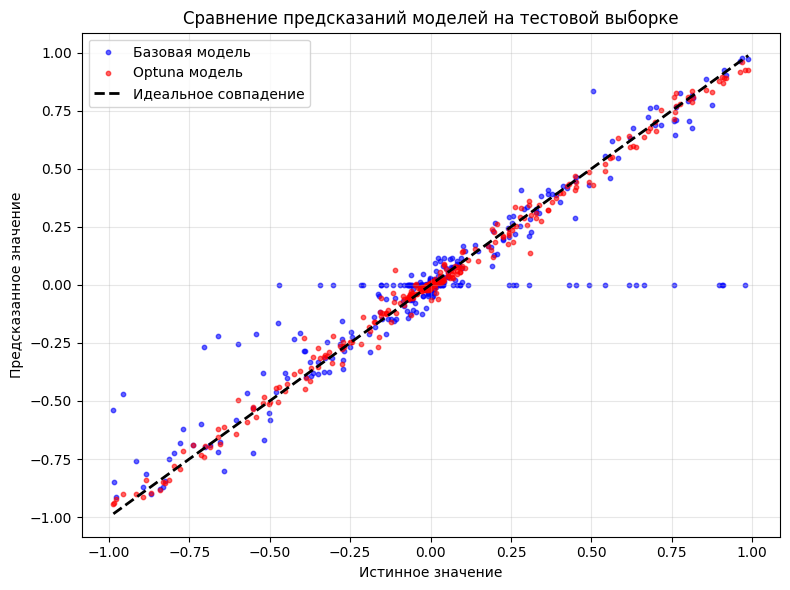

2026-06-01 10:54:03,926 [INFO] График рассеяния сохранён в scatter_comparison.png


In [15]:
# ============================
# 9. График рассеяния: истина vs предсказания (тестовая выборка)
# ============================
# Собираем предсказания обеих моделей на тестовых данных
base_model.eval()
final_model.eval()
y_test_true = torch.FloatTensor(y_test).to(device)

with torch.no_grad():
    y_test_pred_base = base_model(torch.FloatTensor(X_test).to(device)).cpu().numpy()
    y_test_pred_optuna = final_model(torch.FloatTensor(X_test).to(device)).cpu().numpy()
y_test_true_np = y_test_true.cpu().numpy()

# Строим scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_true_np, y_test_pred_base, alpha=0.6, s=10, label='Базовая модель', color='blue')
plt.scatter(y_test_true_np, y_test_pred_optuna, alpha=0.6, s=10, label='Optuna модель', color='red')

# Линия идеального предсказания y = x
min_val = min(y_test_true_np.min(), y_test_pred_base.min(), y_test_pred_optuna.min())
max_val = max(y_test_true_np.max(), y_test_pred_base.max(), y_test_pred_optuna.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Идеальное совпадение')

plt.xlabel('Истинное значение')
plt.ylabel('Предсказанное значение')
plt.title('Сравнение предсказаний моделей на тестовой выборке')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("scatter_comparison.png", dpi=150)
plt.show()
logger.info("График рассеяния сохранён в scatter_comparison.png")